In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [21]:
ma = 213297.350922 # Z*mp + (A-Z)*mn - BindingEnergy/1000 * A; BindingEnergy in keV/c^2 # mA
mb = 1875.612837 # ma
m2 = 214231.993388 # mB
m1 = 938.272013 # mb
Bfield = 2.5
Z = 1
alpha = 299.792458 * Bfield * Z / (np.pi * 2) # MeV / m
c = 299792458 # speed of light in the vacuum (m/s)

In [30]:
T = 8 * 229
Ex = [0, 0.5, 1., 1.5, 2.5, 4, 6, 7, 8, 9, 10]
ka = np.sqrt(pow(ma + T, 2) - ma * ma) # eq. 2.5
beta = ka / (ma + mb + T) # eq. 2.5
gamma = 1 / np.sqrt(1 - beta * beta)
Etot = np.sqrt(pow(ma + mb + T,2) - ka * ka) # total energy in CM system, eq. 2.7c


In [31]:
kCM = [np.sqrt( (Etot*Etot - pow(m1 + m2 + ExB,2)) *
               (Etot*Etot - pow(m1 - m2 - ExB,2)) ) / 2 / Etot for ExB in Ex] # eq. 2.7d
slope = alpha * beta

q = [np.sqrt(m1 * m1 + kcm * kcm) for kcm in kCM]# eq. 2.7
y0 = [ qq / gamma - m1 for qq in q] # eq. 2.7a

z = np.linspace(-0.5, 0.15, 200)
# Ex = [0, 0.5, 1., 1.5, 2.5, 4, 6]

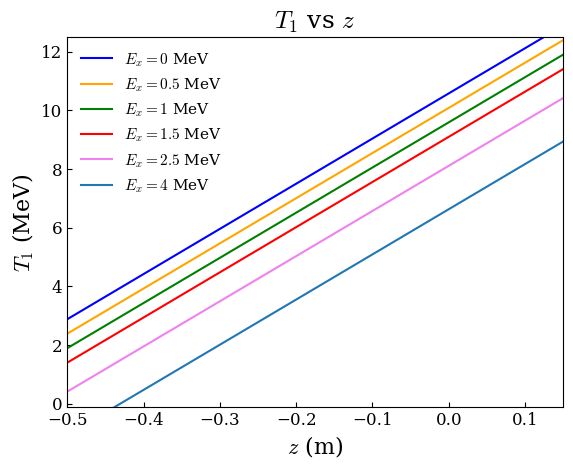

In [133]:
fig, ax = plt.subplots()
ax.plot(z, y0[0] + slope * z, label=r'$E_x=0$ MeV', color = "blue")
ax.plot(z, y0[1] + slope * z, label=r'$E_x=0.5$ MeV', color = "orange")
ax.plot(z, y0[2] + slope * z, label=r'$E_x=1$ MeV', color = "green")
ax.plot(z, y0[3] + slope * z, label=r'$E_x=1.5$ MeV', color = "red")
ax.plot(z, y0[4] + slope * z, label=r'$E_x=2.5$ MeV', color = "violet")
ax.plot(z, y0[5] + slope * z, label=r'$E_x=4$ MeV')
#ax.plot(z, y0[6] + slope * z, label=r'$E_x=6$ MeV')
#ax.plot(z, y0[7] + slope * z, label=r'$E_x=7$ MeV')
#ax.plot(z, y0[8] + slope * z, label=r'$E_x=8$ MeV')
#ax.plot(z, y0[9] + slope * z, label=r'$E_x=9$ MeV')
#ax.plot(z, y0[10] + slope * z, label=r'$E_x=10$ MeV')
# plt.plot(z, y0[6] + slope * z, label=r'$E_x=6$ MeV')
ax.legend(frameon=False)
ax.set_xlabel('$z$ (m)', fontsize=16)
ax.set_ylabel(r'$T_1$ (MeV)', fontsize=16)
ax.set_title(r'$T_1$ vs $z$', fontsize=18)
plt.xticks(fontsize = 12)
plt.yticks(fontsize = 12)
plt.ylim(-0.1, 12.5)
plt.xlim(-0.5, 0.15)
ax.tick_params(direction='in')
#plt.savefig('T_vs_z.png', dpi=1000)
plt.savefig('T_vs_z.pdf')

In [35]:
a = 0.025 # m
thetacm = [np.pi / np.log(100) * (np.log(100) - np.log(100-i)) for i in range(1, 100)]
temp = [np.pi * 2 * slope / beta / kcm * a / np.sin(thetacm) for kcm in kCM]
px = [[beta / slope * (gamma * beta * qq - gamma * kcm * np.cos(thetacm)) * (1 - np.arcsin(temp) / np.pi / 2) for qq in q] for kcm in kCM]
py = [[gamma * qq - m1 - gamma * beta * kcm * np.cos(thetacm) for qq in q] for kcm in kCM]

/var/folders/sn/zq32cl414rs35l8111tdvyd80000gp/T/ipykernel_52215/32418296.py:4: RuntimeWarning: invalid value encountered in arcsin
  px = [[beta / slope * (gamma * beta * qq - gamma * kcm * np.cos(thetacm)) * (1 - np.arcsin(temp) / np.pi / 2) for qq in q] for kcm in kCM]


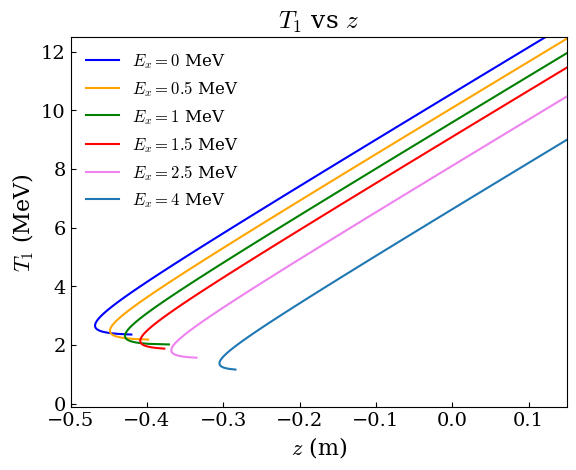

In [132]:
fig, ax = plt.subplots()
ax.plot(px[0][0][0], py[0][0], label=r'$E_x=0$ MeV', color = "blue")
ax.plot(px[1][1][1], py[1][1], label=r'$E_x=0.5$ MeV', color = "orange")
ax.plot(px[2][2][2], py[2][2], label=r'$E_x=1$ MeV', color = "green")
ax.plot(px[3][3][3], py[3][3], label=r'$E_x=1.5$ MeV', color = "red")
ax.plot(px[4][4][4], py[4][4], label=r'$E_x=2.5$ MeV', color = "violet")
ax.plot(px[5][5][5], py[5][5], label=r'$E_x=4$ MeV')
plt.ylim(-0.1, 12.5)
plt.xlim(-0.5, 0.15)
ax.legend(frameon=False, fontsize=12)
ax.set_xlabel('$z$ (m)', fontsize=16)
ax.set_ylabel(r'$T_1$ (MeV)', fontsize=16)
ax.set_title(r'$T_1$ vs $z$', fontsize=18)
plt.xticks(fontsize = 14)
plt.yticks(fontsize = 14)
ax.tick_params(direction='in')
#plt.savefig('T_vs_z_finite_det.png', dpi=1000)
plt.savefig('T_vs_z_finite_det.pdf')

In [12]:
T3 = [qq / gamma - mb + alpha * beta * z for qq in q]

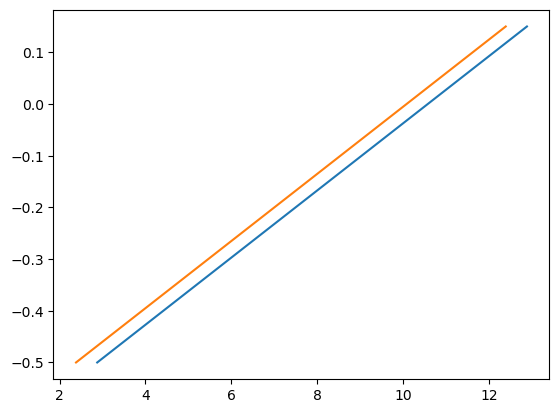

In [15]:
fig, ax = plt.subplots()
ax.plot(T3[0], z)
ax.plot(T3[1], z)

In [16]:
theta_cm = np.linspace(0, 180, 1000)

In [19]:
cos_tcm = np.cos(theta_cm)

In [39]:
Ex = np.array([0, 1, 2, 3, 4])

In [76]:
E_tot_cm = np.sqrt((ma+mb)*(ma+mb)+2*mb*T)
k_cm = np.sqrt(((E_tot_cm*E_tot_cm - (m1+m2+Ex)*(m1+m2+Ex))*(E_tot_cm*E_tot_cm - (m1-m2-Ex)*(m1-m2-Ex))))/(2 * E_tot_cm)
E_light_cm = np.sqrt(k_cm*k_cm + m1*m1)
k_beam_lab = np.sqrt((ma+T)*(ma+T)-ma*ma)
beta_cm = k_beam_lab / (ma + mb + T)
gamma_cm = 1 / np.sqrt(1 - beta_cm*beta_cm)

In [77]:
gamma_cm

1.0084392419907184

In [90]:
e0 = gamma_cm * E_light_cm[0] - m1 + gamma_cm * beta_cm * k_cm[0] * np.cos(theta_cm * np.pi / 180.)
e1 = gamma_cm * E_light_cm[1] - m1 + gamma_cm * beta_cm * k_cm[1] * np.cos(theta_cm * np.pi / 180.)
e2 = gamma_cm * E_light_cm[2] - m1 + gamma_cm * beta_cm * k_cm[2] * np.cos(theta_cm * np.pi / 180.)
e3 = gamma_cm * E_light_cm[3] - m1 + gamma_cm * beta_cm * k_cm[3] * np.cos(theta_cm * np.pi / 180.)
e4 = gamma_cm * E_light_cm[4] - m1 + gamma_cm * beta_cm * k_cm[4] * np.cos(theta_cm * np.pi / 180.)

In [107]:
mb = 213297.350922 # Z*mp + (A-Z)*mn - BindingEnergy/1000 * A; BindingEnergy in keV/c^2 # mA
ma = 1875.612837 # ma
m2 = 214231.993388 # mB
m1 = 938.272013

T = 2 * 8

In [108]:
E_tot_cm = np.sqrt((ma+mb)*(ma+mb)+2*mb*T)
k_cm = np.sqrt(((E_tot_cm*E_tot_cm - (m1+m2+Ex)*(m1+m2+Ex))*(E_tot_cm*E_tot_cm - (m1-m2-Ex)*(m1-m2-Ex))))/(2 * E_tot_cm)
E_light_cm = np.sqrt(k_cm*k_cm + m1*m1)
k_beam_lab = np.sqrt((ma+T)*(ma+T)-ma*ma)
beta_cm = k_beam_lab / (ma + mb + T)
gamma_cm = 1 / np.sqrt(1 - beta_cm*beta_cm)

In [109]:
M = m1 * m2 / ma / mb

In [110]:
E_tot_cm

215188.82370620794

In [111]:
E0 = gamma_cm * E_light_cm[0] - m1 - gamma_cm * beta_cm * k_cm[0] * np.cos(theta_cm * np.pi / 180.)
E1 = gamma_cm * E_light_cm[1] - m1 - gamma_cm * beta_cm * k_cm[1] * np.cos(theta_cm * np.pi / 180.)
E2 = gamma_cm * E_light_cm[2] - m1 - gamma_cm * beta_cm * k_cm[2] * np.cos(theta_cm * np.pi / 180.)
E3 = gamma_cm * E_light_cm[3] - m1 - gamma_cm * beta_cm * k_cm[3] * np.cos(theta_cm * np.pi / 180.)
E4 = gamma_cm * E_light_cm[4] - m1 - gamma_cm * beta_cm * k_cm[4] * np.cos(theta_cm * np.pi / 180.)

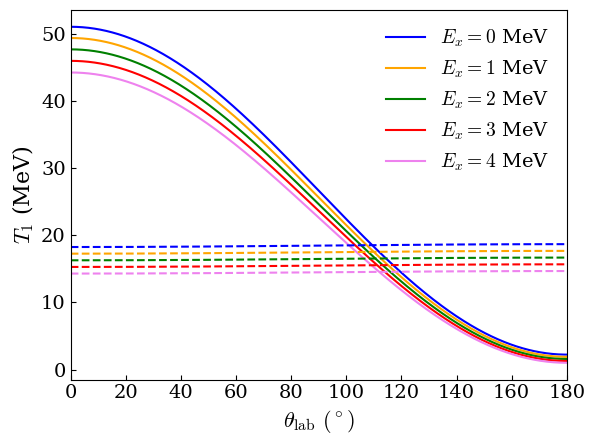

In [137]:
fig, ax = plt.subplots()
ax.plot(theta_cm, e0, label=r'$E_x=0$ MeV', color = "blue")
ax.plot(theta_cm, e1, label=r'$E_x=1$ MeV', color = "orange")
ax.plot(theta_cm, e2, label=r'$E_x=2$ MeV', color = "green")
ax.plot(theta_cm, e3, label=r'$E_x=3$ MeV', color = "red")
ax.plot(theta_cm, e4, label=r'$E_x=4$ MeV', color = "violet")

ax.plot(theta_cm, E0,  color = "blue", linestyle='--')
ax.plot(theta_cm, E1,  color = "orange", linestyle='--')
ax.plot(theta_cm, E2,  color = "green", linestyle='--')
ax.plot(theta_cm, E3,  color = "red", linestyle='--')
ax.plot(theta_cm, E4,  color = "violet", linestyle='--')

plt.xlim(0, 180)
ax.legend(frameon=False, fontsize=14)
ax.set_xlabel(r"$\theta_{\mathrm{lab}}$ $(^\circ)$", fontsize=16)
ax.set_ylabel(r'$T_1$ (MeV)', fontsize=16)
plt.xticks(fontsize = 14)
plt.yticks(fontsize = 14)
ax.tick_params(direction='in')

plt.savefig('inv_vs_normal.pdf')

In [120]:
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = 12  # default font size
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["legend.fontsize"] = 11
plt.rcParams["xtick.labelsize"] = 11
plt.rcParams["ytick.labelsize"] = 11

plt.rcParams["font.family"] = "serif"
plt.rcParams["font.sans-serif"] = ["Helvetica", "Arial", "DejaVu Sans"]

plt.rcParams["mathtext.fontset"] = "cm"